# Save the data in the right format

In [1]:
import numpy as np
import h5py
from scipy import ndimage
import os
import matplotlib.pyplot as plt
import random

import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from dataset import SuperResolutionDataset
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import time

import torchmetrics
from skimage.metrics import structural_similarity as ssim


import wandb



In [2]:
# Preprocess and save npy arrays into hdf5 files
jw = np.load('../data/jwst_cosmos_66px_F115W.npy')
eu = np.load('../data/nisp_cosmos_44px_Y.npy')


In [3]:
# Check if file exists and delete it
if os.path.exists("../data/Nisp_train_cosmos.hdf5"):
    os.remove("../data/Nisp_train_cosmos.hdf5")
if os.path.exists("../data/Nircam_train_cosmos.hdf5"):
    os.remove("../data/Nircam_train_cosmos.hdf5")

# Define dataset size
sample_size = len(jw)
train_size = int(sample_size * 0.8)  # 80% Training
test_size = sample_size - train_size  # 20% Testing

tfms = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Create HDF5 files with train & test splits
hdf5_lr = h5py.File('../data/Nisp_train_cosmos.hdf5', mode='w')
hdf5_lr.create_dataset("train_img", (train_size, 1, 40, 40), np.float32)
hdf5_lr.create_dataset("test_img", (test_size, 1, 40, 40), np.float32)
hdf5_lr.create_dataset("train_keys", (train_size,), np.float32)
hdf5_lr.create_dataset("test_keys", (test_size,), np.float32)

hdf5_lr["train_keys"][...] = np.arange(train_size)
hdf5_lr["test_keys"][...] = np.arange(test_size)

hdf5_hr = h5py.File('../data/Nircam_train_cosmos.hdf5', mode='w')
hdf5_hr.create_dataset("train_img", (train_size, 1, 66, 66), np.float32)
hdf5_hr.create_dataset("test_img", (test_size, 1, 66, 66), np.float32)
hdf5_hr.create_dataset("train_keys", (train_size,), np.float32)
hdf5_hr.create_dataset("test_keys", (test_size,), np.float32)

hdf5_hr["train_keys"][...] = np.arange(train_size)
hdf5_hr["test_keys"][...] = np.arange(test_size)

# Shuffle indices for better train-test separation
indices = np.arange(sample_size)
np.random.shuffle(indices)

# Split into train and test sets
train_indices = indices[:train_size]
test_indices = indices[train_size:]

for i, idx in enumerate(train_indices):
    # --- Process Low-Resolution Image ---
    pashe_lr = np.zeros((1, 40, 40))
    imnisp = eu[idx,:,:]  
    da_lr = np.arcsinh(imnisp)
    pash_lr = (da_lr - da_lr.min()) / (da_lr.max() - da_lr.min() + 1e-8)
    pashe_lr[0, :, :] = pash_lr#tfms(pash_lr.astype(np.float32))  
    hdf5_lr["train_img"][i, ...] = pashe_lr  

    # --- Process High-Resolution Image ---
    pashe_hr = np.zeros((1, 66, 66))
    imnircam = jw[idx,:,:]  
    da_hr = np.arcsinh(imnircam)
    pash_hr = (da_hr - da_hr.min()) / (da_hr.max() - da_hr.min() + 1e-8)
    pashe_hr[0, :, :] = pash_hr#tfms(pash_hr.astype(np.float32))

    hdf5_hr["train_img"][i, ...] = pashe_hr  

for i, idx in enumerate(test_indices):
    # --- Process Low-Resolution Image ---
    imnisp = eu[idx,:,:]  
    pashe_lr = np.zeros((1, 40, 40))

    s_lr = ndimage.rotate(imnisp, 0, mode='nearest', reshape=False)
    da_lr = np.arcsinh(s_lr)
    pash_lr = (da_lr - da_lr.min()) / (da_lr.max() - da_lr.min() + 1e-8)
    pashe_lr[0, :, :] = pash_lr#tfms(pash_lr.astype(np.float32))  
    hdf5_lr["test_img"][i, ...] = pashe_lr  

    # --- Process High-Resolution Image ---
    imnircam = jw[idx,:,:]  
    pashe_hr = np.zeros((1, 66, 66))

    s_hr = ndimage.rotate(imnircam, 0, mode='nearest', reshape=False)
    da_hr = np.arcsinh(s_hr)
    pash_hr = (da_hr - da_hr.min()) / (da_hr.max() - da_hr.min() + 1e-8)
    pashe_hr[0, :, :] = pash_hr#tfms(pash_hr.astype(np.float32))

    hdf5_hr["test_img"][i, ...] = pashe_hr  

hdf5_hr.close()
hdf5_lr.close()


# Dataloader that works with the hdf5 and can load both lr/hr for training and only lr for inference

In [4]:
# Load Training Dataset (for checking shape)
train_dataset = SuperResolutionDataset("../data/Nisp_train_cosmos.hdf5", "../data/Nircam_train_cosmos.hdf5", split="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Get a batch for training
lr_batch, hr_batch = next(iter(train_loader))
print("Training Mode:")
print("LR Batch Shape:", lr_batch.shape)  # Expected: (16, 1, 40, 40)
print("HR Batch Shape:", hr_batch.shape)  # Expected: (16, 1, 66, 66)

# Load Test Dataset (for evaluation)
test_dataset = SuperResolutionDataset("../data/Nisp_train_cosmos.hdf5", "../data/Nircam_train_cosmos.hdf5", split="test")
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Get a batch for inference (only LR images)
lr_batch, hr_batch = next(iter(test_loader))
print("Inference Mode:")
print("LR Batch Shape:", lr_batch.shape)  # Expected: (16, 1, 40, 40)
print("HR Batch Shape:", hr_batch.shape)  # Expected: (16, 1, 66, 66)


Training Mode:
LR Batch Shape: torch.Size([16, 1, 40, 40])
HR Batch Shape: torch.Size([16, 1, 66, 66])
Inference Mode:
LR Batch Shape: torch.Size([16, 1, 40, 40])
HR Batch Shape: torch.Size([16, 1, 66, 66])


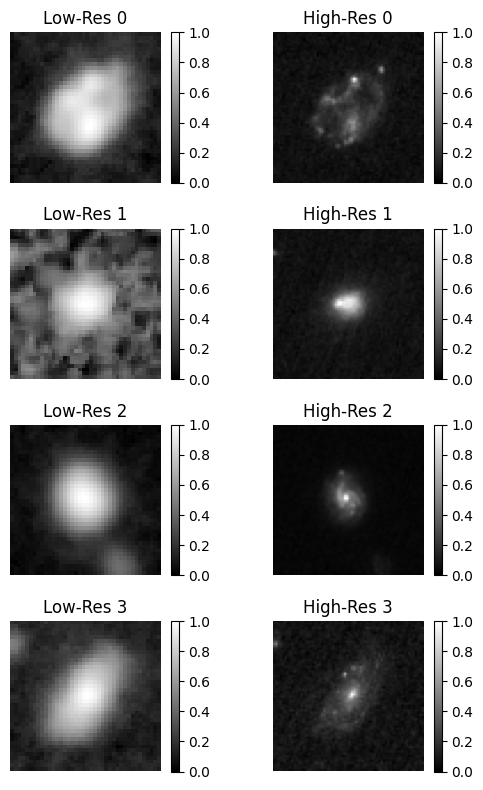

In [5]:
# Define dataset paths
lr_hdf5_path = "../data/Nisp_train_cosmos.hdf5"
hr_hdf5_path = "../data/Nircam_train_cosmos.hdf5"

# Load Training Dataset (set split="train" explicitly)
train_dataset = SuperResolutionDataset(lr_hdf5_path, hr_hdf5_path, split="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Fetch a batch from the training dataset
lr_batch, hr_batch = next(iter(train_loader))

# Convert tensors to NumPy for visualization
lr_batch_np = lr_batch.squeeze().cpu().numpy()  
hr_batch_np = hr_batch.squeeze().cpu().numpy()  

# Plot first 4 samples
fig, axes = plt.subplots(4, 2, figsize=(6, 8))

for i in range(4):
    # Low-Res Image
    img1 = axes[i, 0].imshow(lr_batch_np[i], cmap='gray')
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)  # Add colorbar

    # High-Res Image
    img2 = axes[i, 1].imshow(hr_batch_np[i], cmap='gray')
    axes[i, 1].set_title(f"High-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)  # Add colorbar

plt.tight_layout()
plt.show()


# Diffusion based model

In [ ]:

class SuperResDiffusionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, hidden_dim=64, activation_fn=nn.ReLU):
        super().__init__()

        self.activation_fn = activation_fn  # Store the class, not an instance

        # Encoder
        self.encoder1 = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, kernel_size=4, stride=2, padding=1),
            self.activation_fn(),  # Instantiate it here
        )
        self.encoder2 = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim * 2, kernel_size=4, stride=2, padding=1),
            self.activation_fn(),
        )
        self.encoder3 = nn.Sequential(
            nn.Conv2d(hidden_dim * 2, hidden_dim * 4, kernel_size=4, stride=2, padding=1),
            self.activation_fn(),
        )

        # Condition Projection
        self.condition_proj = nn.Conv2d(1, hidden_dim * 4, kernel_size=3, padding=1)

        # Cross-Attention
        self.cross_attention = nn.Conv2d(hidden_dim * 4 * 2, hidden_dim * 4, kernel_size=1)

        # Decoder
        self.decoder1 = nn.Sequential(
            nn.ConvTranspose2d(hidden_dim * 4, hidden_dim * 2, kernel_size=4, stride=2, padding=1, output_padding=1),
            self.activation_fn(),
        )
        self.decoder2 = nn.Sequential(
            nn.ConvTranspose2d(hidden_dim * 2, hidden_dim, kernel_size=4, stride=2, padding=1, output_padding=1),
            self.activation_fn(),
        )
        self.decoder3 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)

    def forward(self, x, condition):
        x1 = self.encoder1(x)
        x2 = self.encoder2(x1)
        x3 = self.encoder3(x2)

        condition = self.condition_proj(condition)
        condition = F.interpolate(condition, size=(x3.shape[2], x3.shape[3]), mode="bilinear", align_corners=True)

        x3 = torch.cat([x3, condition], dim=1)
        x3 = self.cross_attention(x3)

        x = self.decoder1(x3)
        x = self.align_dims(x, x2)  # Alignment before adding
        x = x + x2  # Skip connection

        x = self.decoder2(x)
        x = self.align_dims(x, x1)  # Alignment before adding
        x = x + x1  # Skip connection

        x = self.decoder3(x)
        return x

    def align_dims(self, x, target):
        if x.size() != target.size():
            diffY = target.size(2) - x.size(2)
            diffX = target.size(3) - x.size(3)
            x = F.pad(x, [diffX // 2, diffX - diffX // 2,
                          diffY // 2, diffY - diffY // 2])
        return x


# Upsampler that ensures output is exactly 66×66
class Upsampler(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, upscale_factor=2):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels * (upscale_factor ** 2), kernel_size=3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x):
        x = x.to(next(self.parameters()).device)
        x = self.relu(self.pixel_shuffle(self.conv1(x)))
        x = self.conv2(x)
        return x


# Diffusion Model with Cosine Noise Schedule
def cosine_schedule(t, total_timesteps=500):
    return torch.cos((t / total_timesteps) * (0.5 * torch.pi))


class DiffusionModel(nn.Module):
    def __init__(self, unet_model, timesteps=500):
        super().__init__()
        self.unet = unet_model
        self.timesteps = timesteps

    def forward(self, x, t, condition):
        x = x.to(next(self.parameters()).device)
        t = t.to(next(self.parameters()).device)
        condition = condition.to(next(self.parameters()).device)
        return self.unet(x, condition)


# Full Super-Resolution Diffusion Model
class SuperResolutionDiffusion(nn.Module):
    def __init__(self, unet_model, upsampler):
        super().__init__()
        self.upsampler = upsampler
        self.diffusion = DiffusionModel(unet_model)

    def forward(self, x, t):
        x = x.to(next(self.parameters()).device)
        t = t.to(next(self.parameters()).device)

        upscaled = self.upsampler(x)

        # Add progressive noise with cosine schedule
        noise = torch.randn_like(upscaled, device=upscaled.device)
        alpha_t = cosine_schedule(t, self.diffusion.timesteps).view(-1, 1, 1, 1)
        noisy_image = alpha_t * upscaled + (1 - alpha_t) * noise

        output = self.diffusion(noisy_image, t, upscaled)

        # Final size correction
        return nn.functional.interpolate(output, size=(66, 66), mode="bilinear", align_corners=True)

# Instantiate models and move them to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

# Example input on GPU
x = torch.randn(1, 1, 40, 40, device=device) 
t = torch.tensor([500], device=device) 

# Run the model
output = model(x, t)

print("Output shape:", output.shape)  

# Train

In [ ]:
# Use Mean Squared Error (MSE) Loss for Super-Resolution
criterion = nn.MSELoss()

# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Number of epochs
num_epochs = 10

# Train-Test Dataloaders
train_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train_nonorm.hdf5", "../data/Nircam_train_nonorm.hdf5", split="train", sample_fraction=0.2),
    batch_size=32, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True
)

test_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train_nonorm.hdf5", "../data/Nircam_train_nonorm.hdf5", split="test"),
    batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True
)

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    print(f"Starting Epoch {epoch+1}...") 

    for batch_idx, (lr_batch, hr_batch) in enumerate(train_loader):

        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
        t = torch.randint(0, model.diffusion.timesteps, (lr_batch.shape[0],), device=device)
        
        output = model(lr_batch, t)# Forward pass
        loss = criterion(output, hr_batch)# Compute loss
        epoch_loss += loss.item()
        
        optimizer.zero_grad()# Backpropagation
        loss.backward()
        optimizer.step()

    avg_loss = epoch_loss / len(train_loader)
    elapsed_time = time.time() - start_time

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}, Time: {elapsed_time:.2f}s")

# Save trained model
torch.save(model.state_dict(), "super_resolution_model.pth")
print("Model saved successfully!")


# Evaluate 

In [ ]:
import torch
import wandb
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import random
from dataset import SuperResolutionDataset  
from model import SuperResDiffusionUNet,Upsampler,SuperResolutionDiffusion

# Load model
checkpoint_path = "super_resolution_model.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

# Define DataLoader with num_workers for speed

test_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train_nonorm.hdf5", "../data/Nircam_train_nonorm.hdf5", split="test", sample_fraction=0.1),
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

# Select a random batch **without loading all**
random_batch_idx = random.randint(0, len(test_loader) - 1)
for i, (lr_batch, hr_batch) in enumerate(test_loader):
    if i == random_batch_idx:
        break

lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

# Generate super-resolution images using AMP (faster)
with torch.no_grad(), torch.cuda.amp.autocast():
    t_test = torch.zeros((lr_batch.shape[0],), dtype=torch.long, device=device)  # t=0 for final reconstruction
    sr_batch = model(lr_batch, t_test).cpu()  # Move back to CPU

# Convert tensors to NumPy for visualization
lr_batch_np = lr_batch.cpu().squeeze().numpy()  
sr_batch_np = sr_batch.cpu().squeeze().numpy()  
hr_batch_np = hr_batch.cpu().squeeze().numpy()  

# Plot results
num_images = min(4, lr_batch.shape[0])
fig, axes = plt.subplots(num_images, 3, figsize=(10, 12))

for i in range(num_images):
    # Low-Resolution Image
    img1 = axes[i, 0].imshow(lr_batch_np[i], cmap='gray')
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # Super-Resolved Image
    img2 = axes[i, 1].imshow(sr_batch_np[i], cmap='gray')
    axes[i, 1].set_title(f"Super-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # High-Resolution Image (Ground Truth)
    img3 = axes[i, 2].imshow(hr_batch_np[i], cmap='gray')
    axes[i, 2].set_title(f"High-Res {i}")
    axes[i, 2].axis("off")
    fig.colorbar(img3, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [ ]:
# PSNR function using torchmetrics
def compute_psnr(pred, target):
    psnr = torchmetrics.functional.image.peak_signal_noise_ratio(pred, target)
    return psnr.item()

# SSIM function using skimage
def compute_ssim(pred, target):
    pred_np = pred.squeeze().cpu().numpy()
    target_np = target.squeeze().cpu().numpy()
    return ssim(pred_np, target_np, data_range=target_np.max() - target_np.min())

# Set model to evaluation mode
model.eval()

# Fetch a test batch from test_loader
test_loader = DataLoader(
    SuperResolutionDataset("../data/Nisp_train.hdf5", "../data/Nircam_train.hdf5", split="test"),
    batch_size=1, shuffle=True, num_workers=0  
)

lr_test, hr_test = next(iter(test_loader))  
lr_test, hr_test = lr_test.to(device), hr_test.to(device)

# Generate super-resolution image
with torch.no_grad():
    t_test = torch.tensor([0], device=device)  # At t=0 for final reconstruction
    predicted_hr = model(lr_test, t_test).cpu()  # Move result to CPU

# Compute PSNR & SSIM
psnr_value = compute_psnr(predicted_hr, hr_test.cpu())
ssim_value = compute_ssim(predicted_hr, hr_test.cpu())

print(f"PSNR: {psnr_value:.2f} dB")
print(f"SSIM: {ssim_value:.3f}")
